# Mangrove NDVI analysis: early warning signals + non-recovery detection + Martinez et al. (2024) scenario framework

Three complementary questions, all handled here:

1. **Early warning signals (prospective)** - Dakos et al. (2012) style. Looks at data *before* a decline for the statistical fingerprint of an approaching tipping point: rising autocorrelation (AR1), rising variance, changing skewness/kurtosis ("critical slowing down"). Tells you a shift may be **coming**.
2. **Non-recovery detection (retrospective)** - looks for a drop in NDVI that does not return to the prior healthy baseline. Tells you a shift **already happened** and, unlike a temporary dip, it stuck.
3. **Martinez, Ardón & Gray (2024) scenario framework** - combines the trend of NDVI itself with the trend of its rolling variance into a 4-scenario matrix (Abrupt Transition / Slowly Transitioning / Recovering / Stable), plus a statistical breakpoint detector and a rule-based Abrupt/Gradual/Variable/None classifier, adapted from their published methodology.

**Important:** when a shift is detected, the EWS indicators (part 1) are computed only on the segment *before* the shift onset, not the whole series. Fitting one smooth trend across an abrupt step blurs it into a gradual slope and produces a spurious spike in variance/autocorrelation right at the transition - a detrending artifact, not a real warning signal. Truncating to the pre-shift window avoids that.

Expects a CSV in the format the GEE annual-max-NDVI export produces: columns `system:index` (point ID), `traj` (GMW trajectory class 1-5), `lon`, `lat`, `year`, `mean` (max NDVI that year), `n_images_that_year`. Note this is **annual** data (one row per point per year), not the monthly time series the pipeline originally used.

Run the cells top to bottom. If the real CSV isn't found, the last section auto-generates synthetic demo data so you can see the pipeline work regardless.

In [121]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
from scipy.stats import kendalltau
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import ruptures as rpt

## Config and parameters

Edit `input_csv` if your file has a different name or path.
Some of these parameters should be rescaled according to the data

In [122]:
CONFIG = {
    "input_csv": "Sisal_Landsat_annual_max_NDVI_per_point3.csv", 
    "output_dir": "ndvi_analysis_output",
    "min_years": 15,            # minimum length of a point's series (YEARS) to bother analyzing
    "max_gap_years": 2,         # interior gaps up to this many years get linearly interpolated
    "min_completeness": 0.6,    # drop a point if less than this fraction of years are real/interpolated data
    "bandwidth_frac": 0.2,      # Gaussian detrending bandwidth, as a fraction of series length
    "window_frac": 0.5,         # rolling window for EWS indicators, as a fraction of series length (Dakos default)
    "window_min_years": 5,      # minimum rolling window size in YEARS - this was hardcoded as 12 (months)
                                 # in the monthly version, which would now wrongly mean a 12-YEAR floor;
                                 # rescaled to a sensible annual equivalent # wat Floris bedoelde??

    "n_surrogates": 400,        # surrogate resamples for significance testing (raise to ~1000 for final results)
    "baseline_frac": 0.25,      # fraction of the START of the series used as the "healthy" reference
    "tail_frac": 0.2,           # fraction of the END of the series checked for recovery
    "drop_k": 1.5,              # a point counts as "dropped" if smoothed NDVI falls this many baseline-SDs below baseline mean
    "recovery_k": 0.75,         # a point counts as "recovered" if the tail mean climbs back above baseline - this many SDs
    "min_duration_years": 2,    # consecutive years below the drop threshold before we call it a real onset (not noise) -
                                 # was 6 MONTHS in the monthly version; 2 years is the annual-scale equivalent judgment call
    "breakpoint_min_size": 5,   # minimum segment length in YEARS for breakpoint detection - was 12 (months)
    "abrupt_mag_threshold": 0.2,     # NDVI drop at a breakpoint bigger than this counts as "Abrupt" (matches paper)
    "gradual_tau_threshold": -0.3,   # NDVI trend tau below this (no sharp breakpoint) counts as "Gradual"
    "variable_cv_threshold": 0.15,   # relative year-to-year volatility above this counts as "Variable"
    "random_seed": 0,
    "apply_image_count_correction": True,   # set False to compare against uncorrected results
}

## 1. Loading and preprocessing

In [123]:
def load_long_csv(path):
    """
    Load the (point_id, traj, lon, lat, year, ndvi, n_images_that_year)
    long-format CSV produced by the GEE annual-max-NDVI export. Column
    names match that export exactly:
      point_id, traj, lon, lat, year, mean, n_images_that_year

    IMPORTANT: point_id is a STABLE per-point ID explicitly set in the GEE
    script (copied from system:index before the per-year .flatten() runs).
    Do NOT rename from 'system:index' here - flatten() reassigns
    system:index to a composite (year-index)_(point-index) label, which is
    a DIFFERENT value for the same point in every year of output. Grouping
    by that instead of the real point_id silently turns every (point, year)
    pair into its own fake "point" with one row of data each - which is
    exactly what happened before this was fixed (thousands of 1-row
    "points", every one dropped for insufficient data).

    'year' is a plain integer in the CSV - converted to a Jan-1 datetime so
    the rest of the pipeline (built around a DatetimeIndex) works unchanged.
    """
    df = pd.read_csv(path)
    if "point_id" not in df.columns and "system:index" in df.columns:
        # Backward compatibility only - this path means the GEE export is
        # the OLD version without an explicit point_id column, and will
        # reproduce the flatten-scrambled-ID bug for any multi-year export.
        print("WARNING: no 'point_id' column found - falling back to "
              "'system:index', which is NOT reliable across multiple years "
              "of a flattened export. Re-export from the updated GEE script.")
        df = df.rename(columns={"system:index": "point_id"})

    if "ndvi_max" in df.columns:
        df = df.rename(columns={"ndvi_max": "ndvi"})
        print("Loaded MAX-composite NDVI data.")
    elif "ndvi_median" in df.columns:
        df = df.rename(columns={"ndvi_median": "ndvi"})
        print("Loaded MEDIAN-composite NDVI data.")
    else:
        raise ValueError(
            "Neither 'ndvi_max' nor 'ndvi_median' found in the CSV columns: "
            f"{list(df.columns)}. Check the GEE export's COMPOSITE_METHOD "
            "and column selectors."
        )

    df["date"] = pd.to_datetime(df["year"], format="%Y")
    return df[["point_id", "date", "ndvi", "traj", "lon", "lat", "n_images_that_year"]]


def extract_point_metadata(df):
    """traj/lon/lat are constant per point (not per year) - pull them into
    a lookup table keyed by point_id, so they can be attached to the
    results summary once rather than repeated on every (point, year) row."""
    return df.groupby("point_id")[["traj", "lon", "lat"]].first()


def regularize_to_annual(df, max_gap_years=2, min_completeness=0.6):
    """
    Turn the (point, year) long table into a regular annual grid per
    point. The GEE export already produces at most one row per point per
    year (an annual max-NDVI composite) - unlike the old monthly version,
    there's no need to aggregate multiple observations within a period.
    This mainly handles YEARS WITH ZERO COVERAGE, which the GEE script
    already drops from the export - those show up here as missing years
    to (optionally) interpolate, not as rows to average.
    """
    wide = df.pivot_table(index="date", columns="point_id", values="ndvi", aggfunc="mean")
    annual = wide.resample("YS").mean()  # "YS" = year start; inserts NaN rows for any missing calendar years
    interpolated = annual.interpolate(method="linear", limit=max_gap_years, limit_area="inside")

    completeness = interpolated.notna().mean()
    keep = completeness[completeness >= min_completeness].index
    dropped = completeness[completeness < min_completeness].index.tolist()

    cleaned = interpolated[keep]
    # Trim each column to its own valid range, then fill any remaining small
    # edge gaps. Same simplification noted in the monthly version - a proper
    # gap-aware estimator would be more rigorous, but is reasonable given
    # min_completeness already filters out the worst-affected points.
    cleaned = cleaned.apply(lambda s: s.loc[s.first_valid_index():s.last_valid_index()])
    cleaned = cleaned.ffill().bfill()

    return cleaned, dropped

In [124]:
def apply_image_count_correction(df):
    """
    Corrects the systematic upward drift in max-NDVI caused by an
    increasing number of available Landsat images per year (more
    candidate images per year mechanically raises the expected value of
    a MAX composite regardless of true vegetation change - confirmed via
    Kendall tau=0.606 between image count and year; tau=0.249, p=0.022
    still remains in the corrected series, meaning this reduces but does
    NOT fully eliminate the drift).

    Fits ONE global linear relationship between ndvi and
    n_images_that_year across all points combined, then subtracts the
    predicted image-count effect from every row. This is a coarse,
    dataset-wide correction, not per-point or nonlinear - a reasonable
    first-pass fix, worth revisiting (e.g. re-exporting from GEE with a
    median/percentile composite instead of max) if this becomes your
    long-term approach rather than a sensitivity check.
    """
    coef = np.polyfit(df['n_images_that_year'], df['ndvi'], deg=1)
    df = df.copy()
    df['ndvi_raw'] = df['ndvi']  # keep the original around for comparison
    df['ndvi'] = df['ndvi'] - np.polyval(coef, df['n_images_that_year'])
    print(f"Applied image-count correction (fitted slope: {coef[0]:.5f} NDVI per additional image/year)")
    return df

## 1a trend of ndvi 

## 2. Detrending

In [125]:
def detrend_gaussian(series, bandwidth_frac=0.2):
    """
    Gaussian-kernel smoothing to estimate the trend, then subtract it to get
    residuals - the same detrending approach used in the 'earlywarnings' R
    package (Dakos et al. 2012). EWS indicators are computed on the
    residuals, not the raw series, so a real long-term trend doesn't get
    mistaken for rising variance/autocorrelation.
    """
    n = len(series)
    sigma = max(1.0, bandwidth_frac * n)
    trend = gaussian_filter1d(series.values.astype(float), sigma=sigma, mode="nearest")
    residual = series.values - trend
    return (pd.Series(residual, index=series.index),
            pd.Series(trend, index=series.index))

## 3. Rolling EWS indicators (Tier 1: AR1, SD, skewness, kurtosis)

In [126]:
def rolling_ar1(x, window):
    """Rolling lag-1 autocorrelation. x is a numpy array."""
    n = len(x)
    out = np.full(n, np.nan)
    for i in range(window, n + 1):
        seg = x[i - window:i]
        a, b = seg[:-1], seg[1:]
        if np.std(a) == 0 or np.std(b) == 0:
            continue
        out[i - 1] = np.corrcoef(a, b)[0, 1]
    return out


def compute_indicators(residual_series, window):
    """Returns a DataFrame of rolling AR1, SD, skewness, kurtosis, indexed
    the same way as the input (so it lines up on a date axis when plotted)."""
    r = residual_series if isinstance(residual_series, pd.Series) else pd.Series(residual_series)
    return pd.DataFrame({
        "ar1": rolling_ar1(r.values, window),
        "sd": r.rolling(window).std().values,
        "skew": r.rolling(window).skew().values,
        "kurtosis": r.rolling(window).kurt().values,
    }, index=r.index)

## 4. Trend test + surrogate significance testing

In [127]:
def kendall_trend(values):
    """
    Kendall's tau between a series and time. Used both for the EWS
    indicators (below) and, new in this version, for the raw NDVI trend
    itself (Martinez et al. 2024 step 7). NOTE: for the rolling-window
    indicators we use tau itself but NOT scipy's built-in p-value - the
    rolling windows overlap, so successive indicator values aren't
    independent, and the standard p-value would be anti-conservative
    (falsely significant too often). Significance for indicators is
    assessed via surrogates instead (see below); the raw NDVI trend tau is
    reported without a p-value at all, matching the paper's use of tau as a
    descriptive trend strength measure.
    """
    idx = np.arange(len(values))
    mask = ~np.isnan(values)
    if mask.sum() < 10:
        return np.nan
    tau, _ = kendalltau(idx[mask], np.asarray(values)[mask])
    return tau


def surrogate_pvalue(residual_values, window, indicator_key, observed_tau, n_surrogates, rng):
    """
    Null distribution for tau built by shuffling the residuals (destroying
    any real temporal structure) and recomputing the same indicator + trend
    test many times. p-value = fraction of surrogate taus >= the observed
    tau (one-sided: EWS theory predicts an INCREASE in AR1/SD/kurtosis
    approaching a tipping point, not a decrease).

    Caveat: shuffling destroys all autocorrelation, including any that's
    genuinely present but stable (not trending). A stricter test would use
    surrogates that preserve the fitted AR(1) structure while destroying
    only the trend (e.g. simulated AR(1) surrogates) - worth upgrading to
    if these results end up mattering a lot; flagged here as a Tier 2
    refinement rather than built in now.
    """
    surrogate_taus = np.empty(n_surrogates)
    rolling_method = {"sd": "std", "skew": "skew", "kurtosis": "kurt"}
    for i in range(n_surrogates):
        shuffled = rng.permutation(residual_values)
        if indicator_key == "ar1":
            ind = rolling_ar1(shuffled, window)
        else:
            s = pd.Series(shuffled)
            ind = getattr(s.rolling(window), rolling_method[indicator_key])().values
        surrogate_taus[i] = kendall_trend(ind)
    valid = surrogate_taus[~np.isnan(surrogate_taus)]
    if len(valid) == 0 or np.isnan(observed_tau):
        return np.nan
    return float(np.mean(valid >= observed_tau))

## 5. Breakpoint detection (Martinez et al. 2024, step 5 - LandTrendr equivalent)

The paper uses **LandTrendr**, a Google Earth Engine algorithm that fits piecewise-linear segments to a per-pixel time series and calls the segment transitions "breakpoints." LandTrendr itself is GEE-specific and doesn't run outside Earth Engine, so this uses **PELT** (Pruned Exact Linear Time, Killick et al. 2012) via the `ruptures` package instead - a different specific algorithm, but the same conceptual role: statistically-grounded changepoint detection on a time series, rather than eyeballing it.

Like the paper, if no breakpoint is found the full time series is used elsewhere in the analysis - this section's output is a diagnostic + classification input, not a hard requirement.

In [128]:
def detect_breakpoint(series, min_size=12, pen=None):
    """
    Fits piecewise-constant segments and returns the breakpoint with the
    LARGEST magnitude level shift (not necessarily the first temporally) -
    matching the paper's framing of a breakpoint as "a substantial decline
    breaking the linear path", and their practice of tracking one
    breakpoint per site.

    Returns (breakpoint_date, magnitude). magnitude = (mean before) -
    (mean after), so positive = a decline at the breakpoint. Returns
    (None, None) if the series is too short or no breakpoint is found -
    matching the paper's stated fallback ("if a breakpoint was not
    detected, the full time series was used for analysis").
    """
    values = series.values.astype(float)
    n = len(values)
    if n < 2 * min_size:
        return None, None

    if pen is None:
        pen = np.log(n) * np.var(values) * 2  # BIC-like penalty, slightly conservative

    algo = rpt.Pelt(model="l2", min_size=min_size).fit(values)
    try:
        breakpoints = algo.predict(pen=pen)
    except Exception:
        return None, None

    breakpoints = [bp for bp in breakpoints if 0 < bp < n]
    if not breakpoints:
        return None, None

    best_bp, best_mag = None, 0.0
    for bp in breakpoints:
        before_mean = values[max(0, bp - min_size):bp].mean()
        after_mean = values[bp:bp + min_size].mean()
        mag = before_mean - after_mean
        if abs(mag) > abs(best_mag):
            best_mag = mag
            best_bp = bp

    return series.index[best_bp], best_mag

## 6. Non-recovery / regime-shift detection (retrospective)

**Important assumption:** this treats the *start* of each point's series as the healthy reference period. Reasonable if your record starts before any known disturbance, but worth checking `onset_date` against known events (hurricanes, HURDAT2 records) rather than trusting it blindly - especially for your purposively-selected disturbed sites.

In [129]:
def detect_non_recovery(series, baseline_frac=0.25, tail_frac=0.2,
                         drop_k=1.5, recovery_k=0.75, min_duration_years=2):
    """Did NDVI drop and fail to come back? Defines a healthy baseline from
    the start of the record, looks for a sustained drop below it, and
    checks whether the end of the record climbed back or stayed low."""
    n = len(series)
    baseline_n = max(3, int(n * baseline_frac))
    tail_n = max(3, int(n * tail_frac))

    baseline = series.iloc[:baseline_n]
    tail = series.iloc[-tail_n:]
    baseline_mean, baseline_std = baseline.mean(), baseline.std()

    drop_threshold = baseline_mean - drop_k * baseline_std
    recovery_threshold = baseline_mean - recovery_k * baseline_std

    smoothed = series.rolling(3, min_periods=1, center=True).mean()
    below = smoothed < drop_threshold

    onset_date = None
    run_length = 0
    for date, flag in below.items():
        if flag:
            run_length += 1
            if run_length == min_duration_years:
                onset_date = date - pd.DateOffset(years=min_duration_years - 1)
                break
        else:
            run_length = 0

    tail_mean = tail.mean()
    shift_detected = onset_date is not None
    recovered = bool(tail_mean >= recovery_threshold) if shift_detected else None

    return {
        "baseline_mean": baseline_mean,
        "baseline_std": baseline_std,
        "drop_threshold": drop_threshold,
        "shift_detected": shift_detected,
        "onset_date": onset_date,
        "tail_mean": tail_mean,
        "recovered": recovered,
    }

## 7. Rule-based trajectory shape classification (Martinez et al. 2024, step 8)

The paper's human coders manually looked at each of 403 site time series and labeled them **Abrupt** (drop >0.2 within 1-2 years), **Gradual** (slow decline over 3-5 years), **Variable** (large swings, no clear direction), or **None** (stable). Manually labeling every point isn't practical at scale, so this is a **rule-based proxy** using the breakpoint (section 5) and NDVI trend (computed in the per-point pipeline below).

**This is an approximation, not a replacement for looking at the plots.** Treat a disagreement between this label and what a plot actually shows as a reason to look closer, not as a bug - the paper's own human coders would likely disagree with each other on borderline cases too.

In [130]:
def classify_trajectory_shape(raw_series, breakpoint_date, breakpoint_magnitude, ndvi_tau,
                               abrupt_mag_threshold=0.2, gradual_tau_threshold=-0.3,
                               variable_cv_threshold=0.15):
    """Rule-based analogue to the paper's manual Abrupt/Gradual/Variable/None
    classification - see markdown above for the caveats."""
    mean_val = raw_series.mean()
    volatility = raw_series.diff().std() / mean_val if mean_val not in (0, np.nan) and not np.isnan(mean_val) else np.nan

    if breakpoint_date is not None and breakpoint_magnitude is not None \
            and abs(breakpoint_magnitude) > abrupt_mag_threshold:
        return "Abrupt"
    elif ndvi_tau is not None and not np.isnan(ndvi_tau) and ndvi_tau < gradual_tau_threshold:
        return "Gradual"
    elif not np.isnan(volatility) and volatility > variable_cv_threshold:
        return "Variable"
    else:
        return "None"

## 8. Four-scenario matrix (Martinez et al. 2024, step 10 - the core deliverable)

Combines the Kendall tau trend of **NDVI itself** with the Kendall tau trend of **rolling standard deviation**, using the paper's ball-in-cup quadrant logic:

| | SD trend τ > 0 | SD trend τ < 0 |
|---|---|---|
| **NDVI trend τ < 0** | **Scenario 1** - Abrupt Transition (potential EWS) | **Scenario 2** - Slowly Transitioning (no EWS) |
| **NDVI trend τ > 0** | **Scenario 3** - Recovering | **Scenario 4** - Stable |

In [131]:
SCENARIO_LABELS = {
    1: "Abrupt Transition (potential EWS)",
    2: "Slowly Transitioning (no EWS)",
    3: "Recovering",
    4: "Stable",
}

def classify_scenario(ndvi_tau, sd_tau):
    """Returns an int 1-4, or None if either tau is missing/NaN/exactly
    zero (an edge case not meaningfully assignable to a quadrant)."""
    if ndvi_tau is None or sd_tau is None or np.isnan(ndvi_tau) or np.isnan(sd_tau):
        return None
    if ndvi_tau == 0 or sd_tau == 0:
        return None
    if ndvi_tau < 0 and sd_tau > 0:
        return 1
    elif ndvi_tau < 0 and sd_tau < 0:
        return 2
    elif ndvi_tau > 0 and sd_tau > 0:
        return 3
    elif ndvi_tau > 0 and sd_tau < 0:
        return 4

## 9. Per-point pipeline

In [132]:
def analyze_point(point_id, raw_series, config, rng):
    n_total = len(raw_series)
    if n_total < config["min_years"]:
        return None

    # Non-recovery / shift detection runs FIRST, on the full series - we need
    # to know if/where a transition happened before we can detrend correctly.
    shift_info = detect_non_recovery(
        raw_series,
        baseline_frac=config["baseline_frac"],
        tail_frac=config["tail_frac"],
        drop_k=config["drop_k"],
        recovery_k=config["recovery_k"],
        min_duration_years=config["min_duration_years"],
    )

    # Independent breakpoint detection (Martinez et al. step 5). This is
    # DIFFERENT from shift_info's onset_date above: shift_info uses a fixed
    # baseline-threshold rule, this uses statistical changepoint detection
    # (PELT) - having both gives a cross-check between two independent
    # methods, and feeds the trajectory-shape classifier below.
    bp_date, bp_magnitude = detect_breakpoint(raw_series, min_size=config["breakpoint_min_size"])

    # IMPORTANT: if a shift was detected, restrict the prospective EWS
    # analysis (detrending + rolling indicators) to the segment BEFORE the
    # shift. Fitting one smooth trend across an abrupt step blurs the step
    # into a gradual slope, which then produces a large but SPURIOUS spike
    # in variance/autocorrelation right at the transition - a detrending
    # artifact, not a real early-warning signal. EWS indicators are only
    # meaningful for data leading up to a transition, never data that
    # straddles one.
    if shift_info["shift_detected"] and shift_info["onset_date"] is not None:
        analysis_series = raw_series.loc[:shift_info["onset_date"]].iloc[:-1]
    else:
        analysis_series = raw_series

    result = {"point_id": point_id, "n_years": n_total, "n_preshift_years": len(analysis_series)}
    result.update({f"shift_{k}": v for k, v in shift_info.items()})
    result["breakpoint_date"] = bp_date
    result["breakpoint_magnitude"] = bp_magnitude

    # Raw NDVI trend (Martinez et al. step 7, applied to NDVI itself - not
    # just to the indicators below), computed over the SAME analysis window
    # used for the indicators, so the scenario matrix combines two trends
    # measured over a consistent period.
    tau_ndvi = kendall_trend(analysis_series.values)
    result["tau_ndvi"] = tau_ndvi

    n_analysis = len(analysis_series)
    # Window floor is now config["window_min_years"] (default 5), not a
    # hardcoded 12 - that 12 was a MONTHLY assumption (12 months = 1 year
    # minimum); left as-is it would have wrongly demanded a 12-YEAR minimum
    # window on data that might only span ~40 years total.
    window = max(config["window_min_years"], int(n_analysis * config["window_frac"])) if n_analysis > 0 else None

    if n_analysis < config["min_years"] or window >= n_analysis:
        # Not enough pre-shift data to say anything about early warning
        # signals - still report the shift/non-recovery/breakpoint result.
        for key in ["ar1", "sd", "skew", "kurtosis"]:
            result[f"tau_{key}"] = np.nan
            result[f"p_{key}"] = np.nan
        result["trajectory_shape"] = classify_trajectory_shape(
            raw_series, bp_date, bp_magnitude, tau_ndvi,
            config["abrupt_mag_threshold"], config["gradual_tau_threshold"],
            config["variable_cv_threshold"])
        result["scenario"] = None
        return result, None, None, None

    residual, trend = detrend_gaussian(analysis_series, config["bandwidth_frac"])
    indicators = compute_indicators(residual, window)

    for key in ["ar1", "sd", "skew", "kurtosis"]:
        tau = kendall_trend(indicators[key].values)
        pval = surrogate_pvalue(residual.values, window, key,
                                 tau, config["n_surrogates"], rng)
        result[f"tau_{key}"] = tau
        result[f"p_{key}"] = pval

    # Martinez et al. step 8 (rule-based proxy) and step 10 (4-scenario matrix)
    result["trajectory_shape"] = classify_trajectory_shape(
        raw_series, bp_date, bp_magnitude, tau_ndvi,
        config["abrupt_mag_threshold"], config["gradual_tau_threshold"],
        config["variable_cv_threshold"])
    result["scenario"] = classify_scenario(tau_ndvi, result["tau_sd"])

    return result, residual, trend, indicators



def run_analysis(config):
    os.makedirs(config["output_dir"], exist_ok=True)
    df = load_long_csv(config["input_csv"])
    if config.get("apply_image_count_correction", False):
        df = apply_image_count_correction(df)
    point_meta = extract_point_metadata(df)
    annual, dropped = regularize_to_annual(
        df, config["max_gap_years"], config["min_completeness"]
    )
    if dropped:
        print(f"Dropped {len(dropped)} point(s) for insufficient data coverage: {dropped}")

    rng = np.random.default_rng(config["random_seed"])
    rows = []
    detail = {}  # point_id -> residual/trend/indicators, kept for plotting

    for point_id in annual.columns:
        series = annual[point_id].dropna()
        out = analyze_point(point_id, series, config, rng)
        if out is None:
            continue
        row, residual, trend, indicators = out
        rows.append(row)
        detail[point_id] = {"raw": series, "residual": residual, "trend": trend, "indicators": indicators}

    results_df = pd.DataFrame(rows)
    # Attach the trajectory class (1-5) and coordinates each point was
    # drawn with in GEE, so the summary table is traceable back to the
    # sampling design without a separate join later.
    if len(results_df) > 0:
        results_df = results_df.merge(point_meta, left_on="point_id", right_index=True, how="left")

    out_path = os.path.join(config["output_dir"], "ews_summary.csv")
    results_df.to_csv(out_path, index=False)
    print(f"Analyzed {len(results_df)} points. Summary written to {out_path}")

    if "scenario" in results_df.columns and len(results_df) > 0:
        print("\nScenario breakdown (Martinez et al. 2024 4-scenario matrix):")
        for s in [1, 2, 3, 4]:
            count = int((results_df["scenario"] == s).sum())
            pct = 100 * count / len(results_df)
            print(f"  Scenario {s} ({SCENARIO_LABELS[s]}): {count} points ({pct:.0f}%)")
        n_none = int(results_df["scenario"].isna().sum())
        print(f"  Not classified (insufficient data): {n_none} points")

        print("\nTrajectory shape breakdown (rule-based Abrupt/Gradual/Variable/None):")
        print(results_df["trajectory_shape"].value_counts().to_string())

        if "traj" in results_df.columns:
            print("\nScenario x GMW trajectory class (cross-tab):")
            print(pd.crosstab(results_df["traj"], results_df["scenario"]).to_string())

    return results_df, detail, annual

## 10. Plotting

In [133]:
def plot_point(point_id, detail, results_row, output_dir, save=True):
    raw = detail["raw"]
    residual = detail["residual"]
    trend = detail["trend"]
    indicators = detail["indicators"]

    def fmt_tau(key):
        """Formats a tau value for display on the plot, handling NaN/missing
        gracefully rather than printing 'nan'."""
        val = results_row.get(key) if results_row is not None else None
        if val is None or pd.isna(val):
            return "n/a"
        return f"{val:.2f}"

    fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)

    axes[0].plot(raw.index, raw.values, color="tab:green", label="NDVI")
    if trend is not None:
        axes[0].plot(trend.index, trend.values, color="black", linestyle="--",
                     label="trend (Gaussian, pre-shift only)" if results_row.get("shift_shift_detected") else "trend (Gaussian)")
    if results_row is not None and results_row.get("shift_shift_detected"):
        axes[0].axhline(results_row["shift_drop_threshold"], color="red", linestyle=":", label="drop threshold")
        if pd.notna(results_row.get("shift_onset_date")):
            axes[0].axvline(results_row["shift_onset_date"], color="red", alpha=0.6, label="shift onset")
    if results_row is not None and pd.notna(results_row.get("breakpoint_date")):
        axes[0].axvline(results_row["breakpoint_date"], color="orange", linestyle="-.",
                         alpha=0.7, label="breakpoint (PELT)")
    axes[0].set_ylabel("NDVI")
    axes[0].legend(loc="upper right", fontsize=8)

    title_extra = []
    if results_row is not None:
        if results_row.get("trajectory_shape") and pd.notna(results_row.get("trajectory_shape")):
            title_extra.append(f"shape={results_row['trajectory_shape']}")
        if pd.notna(results_row.get("scenario")):
            title_extra.append(f"scenario={int(results_row['scenario'])}")
    title_suffix = " (" + ", ".join(title_extra) + ")" if title_extra else ""
    axes[0].set_title(f"Point {point_id}{title_suffix}")

    if residual is not None:
        axes[1].plot(residual.index, residual.values, color="tab:blue")
        axes[1].axhline(0, color="gray", linewidth=0.8)
        axes[1].set_ylabel("Detrended\nresidual\n(pre-shift)")
        tau_ndvi_text = fmt_tau("tau_ndvi")
        axes[1].text(0.99, 0.95, f"tau(NDVI) = {tau_ndvi_text}", transform=axes[1].transAxes,
                     ha="right", va="top", fontsize=8, color="tab:blue")
    else:
        axes[1].text(0.5, 0.5, "Not enough pre-shift data for EWS analysis",
                     ha="center", va="center", transform=axes[1].transAxes, fontsize=9, color="gray")

    if indicators is not None:
        axes[2].plot(indicators.index, indicators["ar1"], color="tab:orange", label="AR1")
        ax2b = axes[2].twinx()
        ax2b.plot(indicators.index, indicators["sd"], color="tab:purple", alpha=0.6, label="SD")
        axes[2].set_ylabel("Rolling AR1", color="tab:orange")
        ax2b.set_ylabel("Rolling SD", color="tab:purple")
        axes[2].text(0.99, 0.95, f"tau(AR1) = {fmt_tau('tau_ar1')}   tau(SD) = {fmt_tau('tau_sd')}",
                     transform=axes[2].transAxes, ha="right", va="top", fontsize=8, color="dimgray")

        axes[3].plot(indicators.index, indicators["skew"], color="tab:red", label="skewness")
        ax3b = axes[3].twinx()
        ax3b.plot(indicators.index, indicators["kurtosis"], color="tab:brown", alpha=0.6, label="kurtosis")
        axes[3].set_ylabel("Skewness", color="tab:red")
        ax3b.set_ylabel("Kurtosis", color="tab:brown")
        axes[3].text(0.99, 0.95, f"tau(skew) = {fmt_tau('tau_skew')}   tau(kurt) = {fmt_tau('tau_kurtosis')}",
                     transform=axes[3].transAxes, ha="right", va="top", fontsize=8, color="dimgray")
    axes[3].set_xlabel("Date")

    fig.tight_layout()
    plt.show()
    if save:
        path = os.path.join(output_dir, f"point_{point_id}.png")
        fig.savefig(path, dpi=120)
        plt.close(fig)
        return path
    plt.close(fig)
    return None

## 11. Synthetic demo data

Only used if the real CSV isn't found - lets you see the pipeline work before your real file is ready.

In [134]:
def make_synthetic_demo(n_points=8, n_years=40, seed=1):
    """
    Builds a fake long-format CSV resembling the GEE annual-max-NDVI export
    (system:index, traj, lon, lat, year, ndvi_max, n_images_that_year), with a
    mix of:
      - stable healthy points (noisy, no trend)
      - a point with a temporary dip that recovers
      - a point with an abrupt drop that does NOT recover
      - a point with a gradual decline + rising variance before a shift
        (a textbook critical-slowing-down example)
    Time steps are now YEARS, not months - shift/dip locations below are
    rescaled accordingly (e.g. a dip lasting a few years, not months).
    """
    rng = np.random.default_rng(seed)
    years = np.arange(1985, 1985 + n_years)
    traj_classes = [1, 1, 2, 2, 3, 3, 4, 5]  # spread demo points across the 5 GMW trajectory classes
    rows = []

    for p in range(n_points):
        base = 0.7 + rng.normal(0, 0.02)
        noise_sd = 0.03
        series = base + rng.normal(0, noise_sd, n_years)

        if p == 2:  # temporary dip (a few years), recovers
            series[15:18] -= 0.25
        elif p == 3:  # abrupt drop, no recovery
            series[20:] -= 0.3
        elif p == 4:  # gradual decline + rising variance before a shift
            shift_at = 27
            ramp = np.linspace(0, 1, shift_at)
            series[:shift_at] += -0.15 * ramp + rng.normal(0, noise_sd * (1 + 2 * ramp), shift_at) - rng.normal(0, noise_sd, shift_at)
            series[shift_at:] -= 0.25

        series = np.clip(series, 0.05, 0.95)
        lon = -90.05 + rng.uniform(-0.05, 0.05)
        lat = 21.15 + rng.uniform(-0.05, 0.05)
        traj = traj_classes[p % len(traj_classes)]
        keep_mask = rng.random(n_years) > 0.1  # simulate occasional zero-coverage years (already dropped in GEE)

        for y, v, keep in zip(years, series, keep_mask):
            if keep:
                rows.append({
                    "point_id": f"pt_{p:03d}",
                    "traj": traj,
                    "lon": lon,
                    "lat": lat,
                    "year": int(y),
                    "ndvi_max": v,
                    "n_images_that_year": int(rng.integers(1, 8)),
                })

    return pd.DataFrame(rows)

## Run the analysis

In [135]:
if not os.path.exists(CONFIG["input_csv"]):
    print(f"'{CONFIG['input_csv']}' not found - running on synthetic demo data instead.")
    print("Once your real CSV is in this folder, just re-run the notebook from the top.\n")
    demo_df = make_synthetic_demo()
    demo_path = "demo_ndvi_timeseries.csv"
    demo_df.to_csv(demo_path, index=False)
    CONFIG["input_csv"] = demo_path

results_df, detail, annual = run_analysis(CONFIG)
results_df

Applied image-count correction (fitted slope: 0.00208 NDVI per additional image/year)
Analyzed 288 points. Summary written to ndvi_analysis_output/ews_summary.csv

Scenario breakdown (Martinez et al. 2024 4-scenario matrix):
  Scenario 1 (Abrupt Transition (potential EWS)): 45 points (16%)
  Scenario 2 (Slowly Transitioning (no EWS)): 47 points (16%)
  Scenario 3 (Recovering): 52 points (18%)
  Scenario 4 (Stable): 97 points (34%)
  Not classified (insufficient data): 47 points

Trajectory shape breakdown (rule-based Abrupt/Gradual/Variable/None):
trajectory_shape
Variable    131
Abrupt       86
Gradual      38
None         33

Scenario x GMW trajectory class (cross-tab):
scenario  1.0  2.0  3.0  4.0
traj                        
1          16   15    6    2
2          10   14   10   12
3          18   14   16   17
4           1    1   15   33
5           0    3    5   33


,point_id,n_years,n_preshift_years,shift_baseline_mean,shift_baseline_std,shift_drop_threshold,shift_shift_detected,shift_onset_date,shift_tail_mean,shift_recovered,...,p_sd,tau_skew,p_skew,tau_kurtosis,p_kurtosis,trajectory_shape,scenario,traj,lon,lat
0,c10_001,42,42,-0.279229,0.271009,-0.685743,False,NaT,0.026741,None,...,0.7475,-0.419913,0.7375,-0.523810,0.8400,None,4.0,3,-90.028968,21.158313
1,c10_002,42,42,-0.164486,0.308259,-0.626874,False,NaT,-0.099958,None,...,0.3325,0.220779,0.3825,-0.350649,0.7425,Abrupt,3.0,3,-90.033549,21.158583
2,c10_003,42,42,-0.171875,0.280457,-0.592561,False,NaT,0.026446,None,...,0.3775,-0.281385,0.7125,-0.272727,0.6750,Abrupt,3.0,3,-90.030046,21.158044
3,c10_004,42,42,-0.139368,0.286895,-0.569710,False,NaT,-0.000303,None,...,0.3750,-0.056277,0.5475,-0.160173,0.5950,Abrupt,3.0,3,-90.029507,21.157774
4,c10_005,42,42,-0.112327,0.157474,-0.348538,False,NaT,-0.131344,None,...,0.5900,0.220779,0.3700,-0.393939,0.7225,None,2.0,3,-89.954594,21.163972
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,c5_044,42,10,-0.066652,0.068441,-0.169313,True,1995-01-01,-0.007980,True,...,NaN,NaN,NaN,NaN,NaN,None,NaN,5,-89.973188,21.183374
284,c5_045,42,42,-0.163669,0.174937,-0.426075,False,NaT,0.031975,None,...,0.9125,-0.800866,0.9650,-0.497835,0.8100,None,4.0,5,-90.018998,21.166128
285,c5_046,42,42,-0.084199,0.177310,-0.350165,False,NaT,0.127952,None,...,0.7575,-0.670996,0.9225,0.619048,0.1175,None,4.0,5,-90.067233,21.152115
286,c5_047,42,42,0.161382,0.102253,0.008003,False,NaT,0.071342,None,...,0.7425,0.463203,0.2475,-0.090909,0.5625,Variable,2.0,5,-90.001213,21.154541


## Plot results

Shows the first 5 analyzed points by default - change the slice (or filter `results_df` first, e.g. to only rows where `scenario == 1` for potential EWS points) to look at specific points.

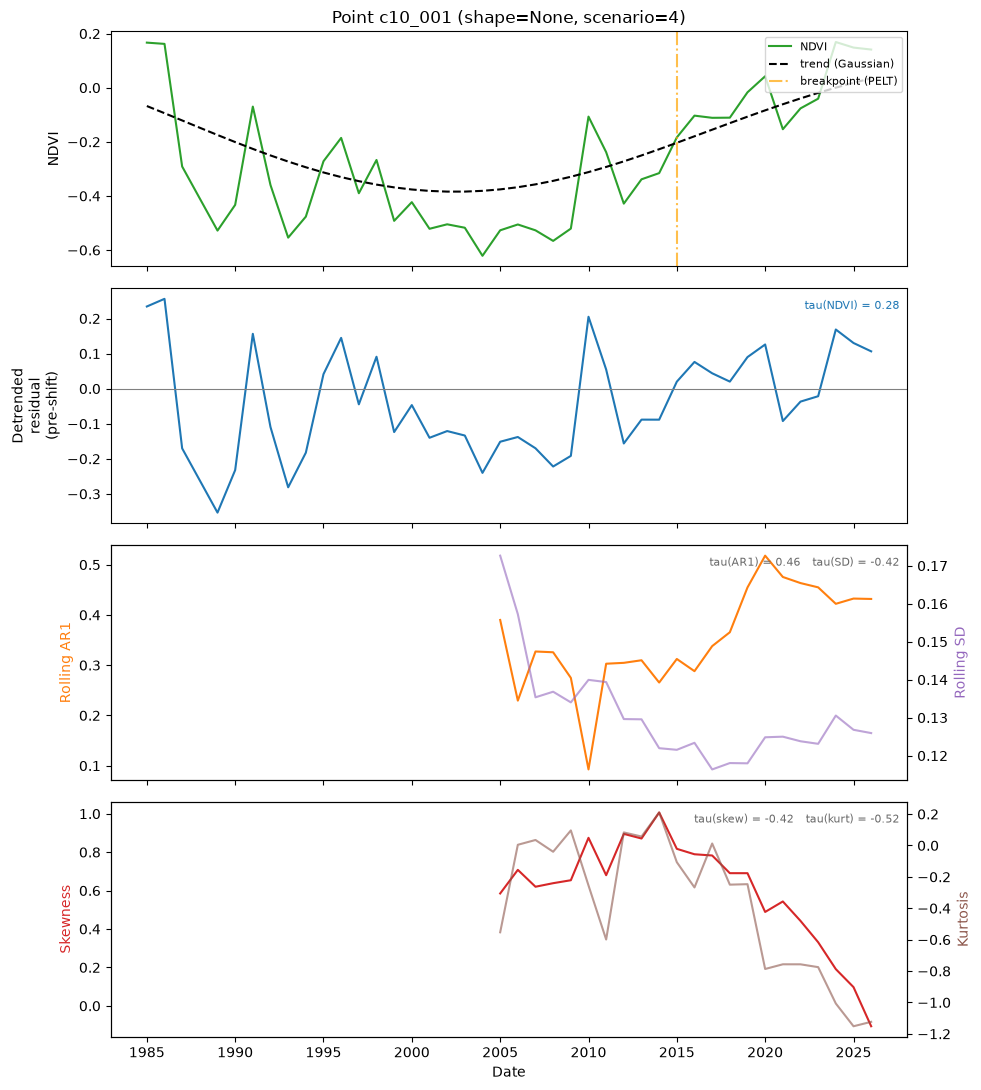

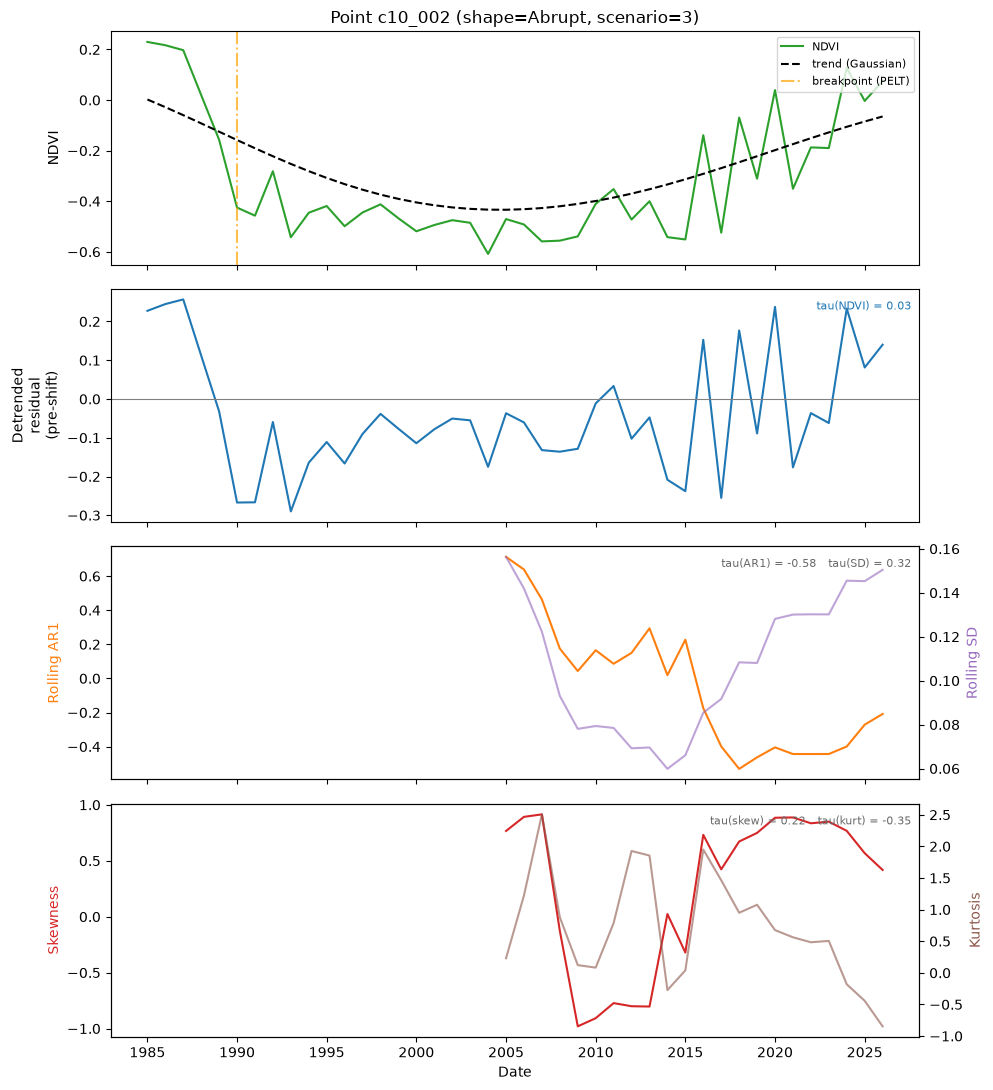

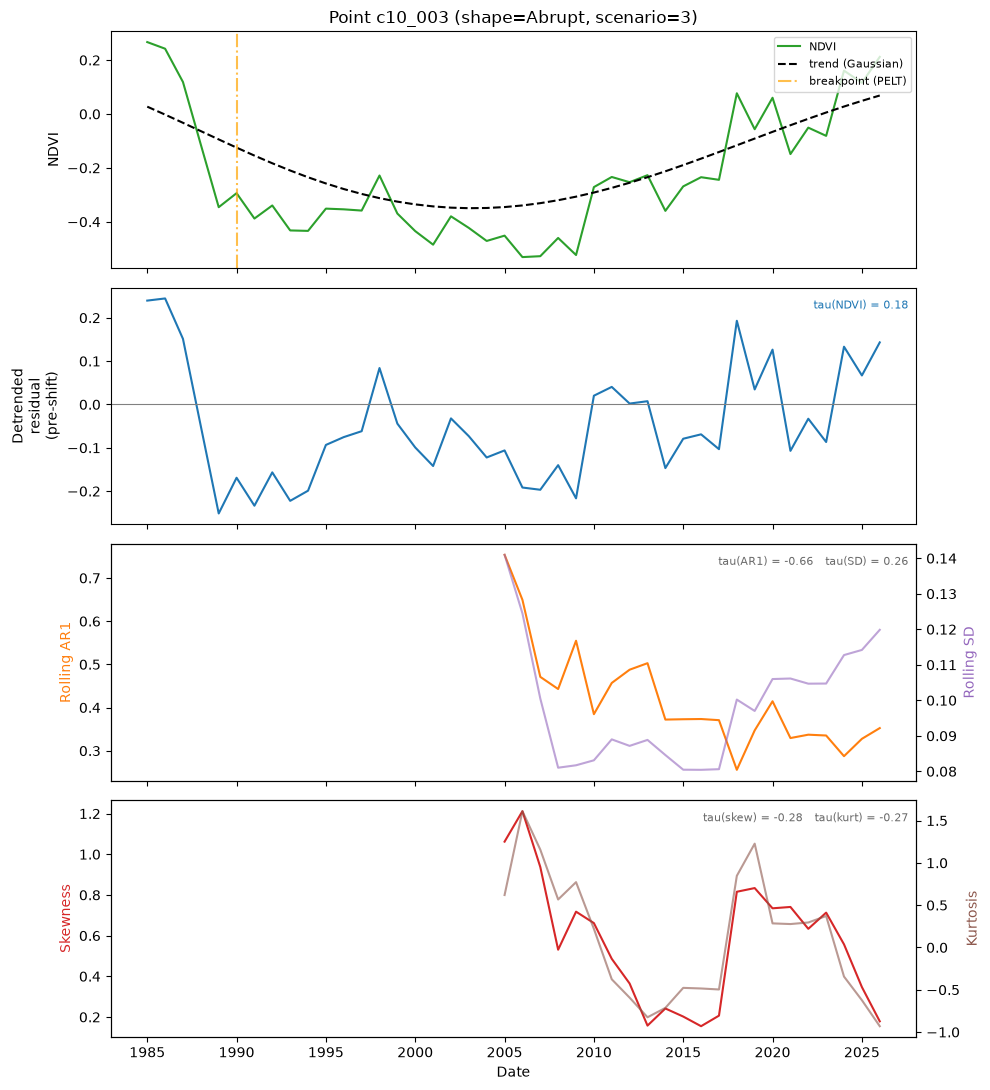

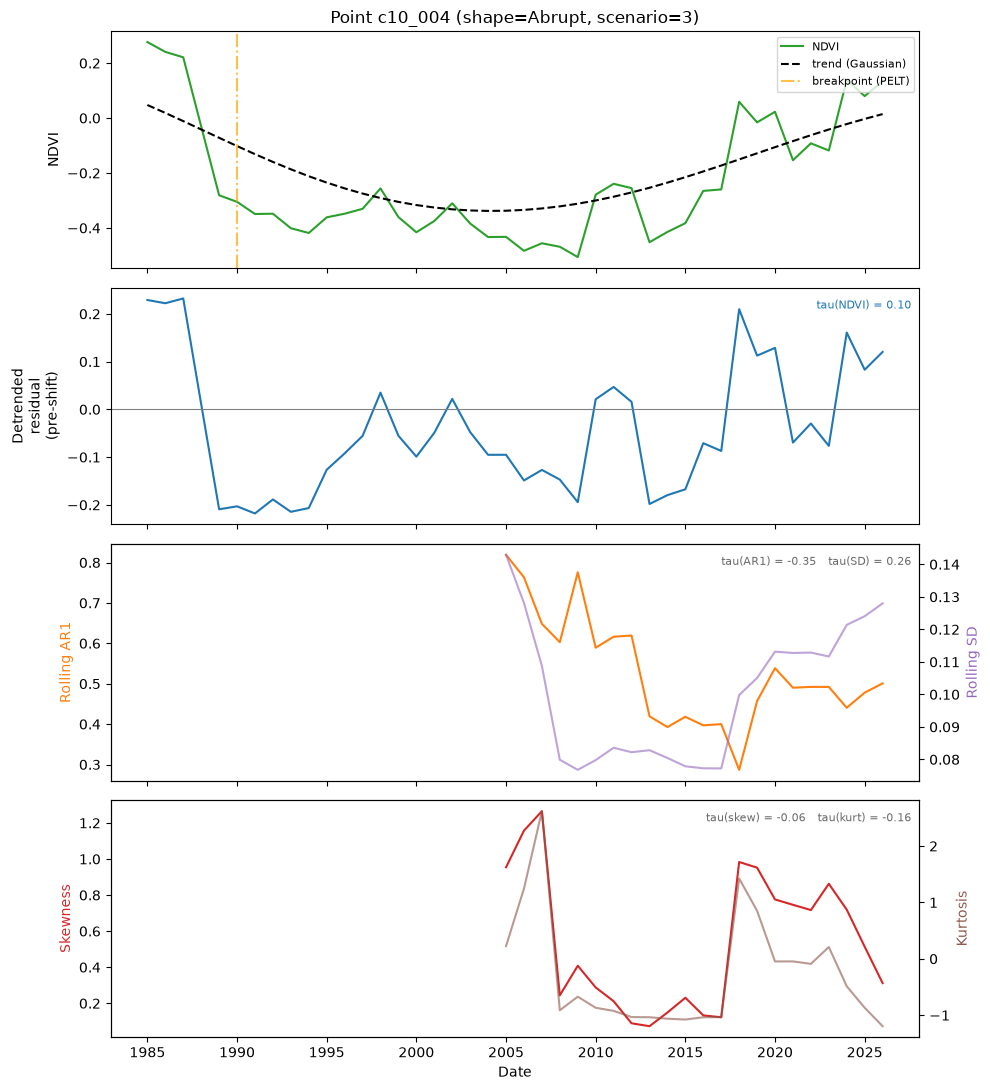

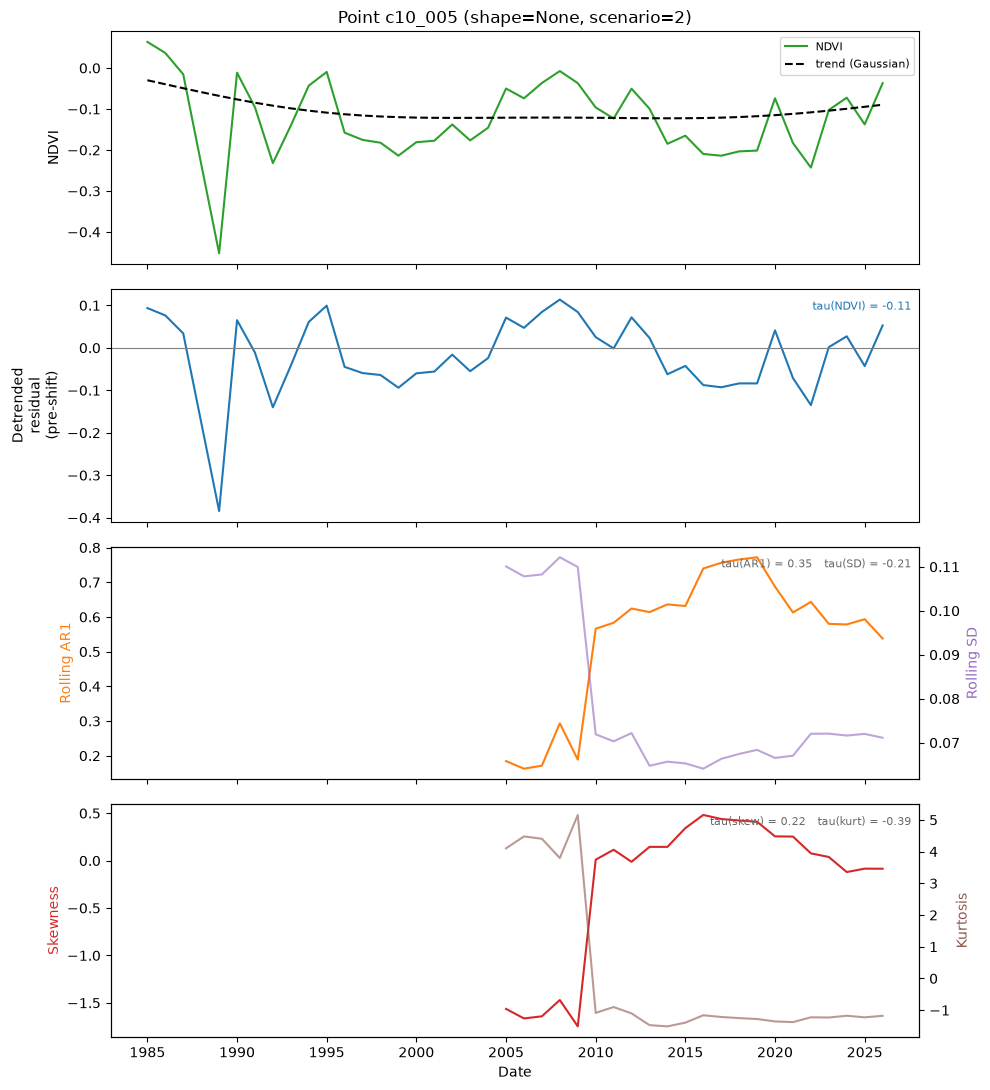

In [136]:
for _, row in results_df.head(5).iterrows():
    pid = row["point_id"]
    plot_point(pid, detail[pid], row, CONFIG["output_dir"])

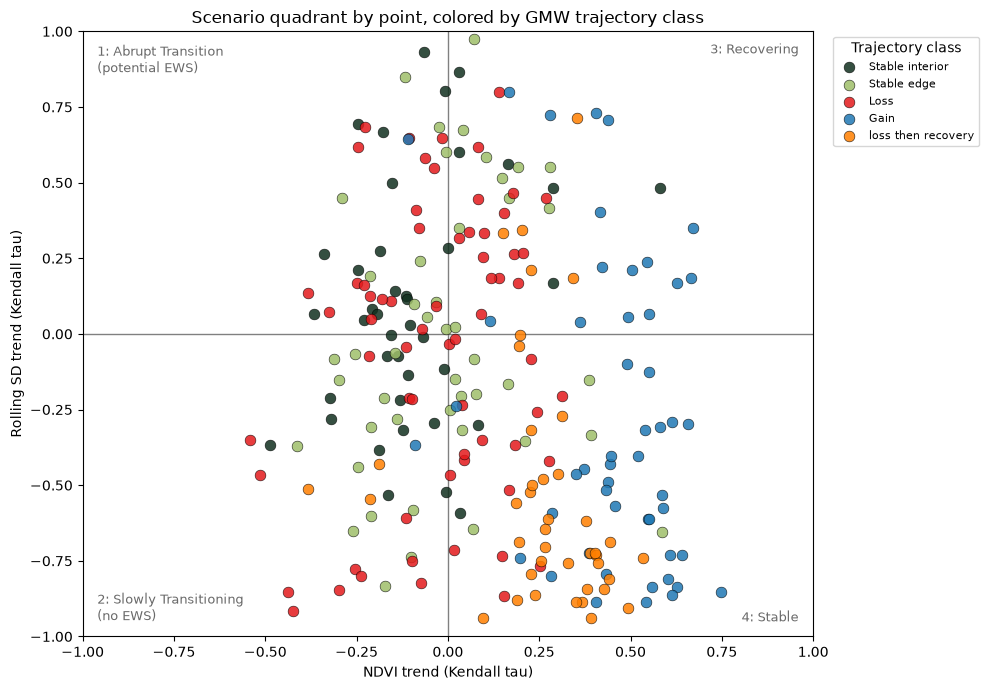

In [138]:
fig, ax = plt.subplots(figsize=(10, 7))

traj_colors = {1: '#12301f', 2: '#9fbf6a', 3: '#e31a1c', 4: '#1f78b4', 5: '#ff7f00'}
traj_labels = {1: 'Stable interior', 2: 'Stable edge', 3: 'Loss',
               4: 'Gain', 5: 'loss then recovery'}

plot_df = results_df.dropna(subset=['tau_ndvi', 'tau_sd'])

for t, group in plot_df.groupby('traj'):
    ax.scatter(group['tau_ndvi'], group['tau_sd'],
               color=traj_colors.get(t, 'gray'), label=traj_labels.get(int(t), f'class {t}'),
               s=60, edgecolor='black', linewidth=0.4, alpha=0.85, zorder=3)

ax.axhline(0, color='gray', linewidth=1, zorder=1)
ax.axvline(0, color='gray', linewidth=1, zorder=1)

# Quadrant labels matching classify_scenario's logic directly
ax.text(0.02, 0.98, '1: Abrupt Transition\n(potential EWS)', transform=ax.transAxes,
        ha='left', va='top', fontsize=9, color='dimgray')
ax.text(0.02, 0.02, '2: Slowly Transitioning\n(no EWS)', transform=ax.transAxes,
        ha='left', va='bottom', fontsize=9, color='dimgray')
ax.text(0.98, 0.98, '3: Recovering', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='dimgray')
ax.text(0.98, 0.02, '4: Stable', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=9, color='dimgray')

ax.set_xlabel('NDVI trend (Kendall tau)')
ax.set_ylabel('Rolling SD trend (Kendall tau)')
ax.set_title('Scenario quadrant by point, colored by GMW trajectory class')
ax.legend(title='Trajectory class', loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
fig.tight_layout()
plt.show()

In [118]:
from scipy import stats

tau_metrics = ['tau_ar1', 'tau_sd', 'tau_skew', 'tau_kurtosis']
loss_points = results_df[results_df['traj'] == 3]
stable_points = results_df[results_df['traj'] == 1]

print(f"{'metric':12s} {'loss median':>12s} {'stable median':>14s} {'Mann-Whitney p':>16s}")
for m in tau_metrics:
    loss_vals = loss_points[m].dropna()
    stable_vals = stable_points[m].dropna()
    if len(loss_vals) > 3 and len(stable_vals) > 3:
        _, p = stats.mannwhitneyu(loss_vals, stable_vals, alternative='two-sided')
    else:
        p = float('nan')
    print(f"{m:12s} {loss_vals.median():12.3f} {stable_vals.median():14.3f} {p:16.3f}")

metric        loss median  stable median   Mann-Whitney p
tau_ar1            -0.317          0.108            0.020
tau_sd             -0.033         -0.017            0.807
tau_skew            0.117          0.017            0.960
tau_kurtosis       -0.099         -0.316            0.277


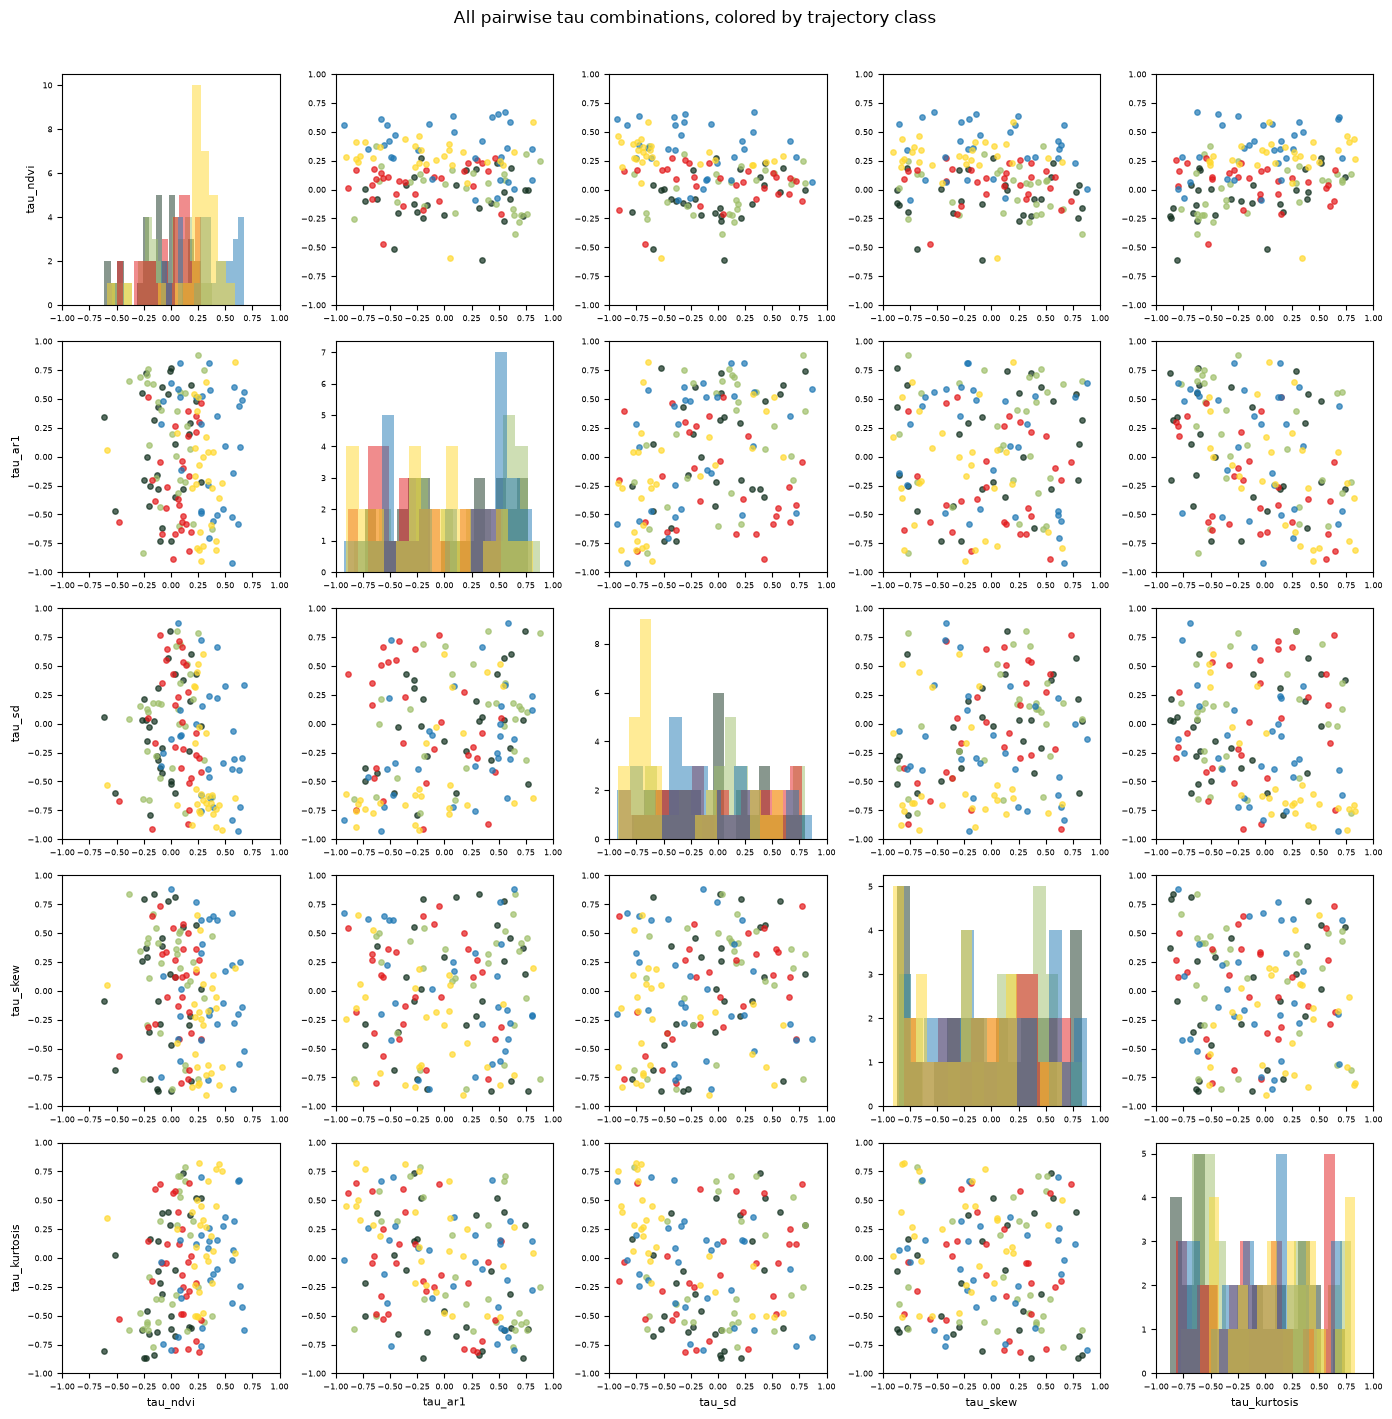

In [117]:
tau_cols = ['tau_ndvi', 'tau_ar1', 'tau_sd', 'tau_skew', 'tau_kurtosis']
traj_colors = {1: '#12301f', 2: '#9fbf6a', 3: '#e31a1c', 4: '#1f78b4', 5: '#ffd92f'}

n = len(tau_cols)
fig, axes = plt.subplots(n, n, figsize=(14, 14))
for i, yvar in enumerate(tau_cols):
    for j, xvar in enumerate(tau_cols):
        ax = axes[i, j]
        if i == j:
            for t, group in results_df.groupby('traj'):
                ax.hist(group[xvar].dropna(), color=traj_colors.get(t, 'gray'), alpha=0.5, bins=15)
        else:
            for t, group in results_df.groupby('traj'):
                ax.scatter(group[xvar], group[yvar], color=traj_colors.get(t, 'gray'), s=15, alpha=0.7)
            ax.set_ylim(-1, 1)
        ax.set_xlim(-1, 1)
        if i == n - 1:
            ax.set_xlabel(xvar, fontsize=8)
        if j == 0:
            ax.set_ylabel(yvar, fontsize=8)
        ax.tick_params(labelsize=6)
fig.suptitle('All pairwise tau combinations, colored by trajectory class', y=1.01)
fig.tight_layout()
plt.show()

In [112]:
def classify_scenario_kurtosis(ndvi_tau, kurtosis_tau):
    """
    Kurtosis-based variant of the Martinez et al. 4-scenario matrix, using
    the SAME quadrant logic but swapping in kurtosis trend instead of SD
    trend - since the Mann-Whitney screening showed kurtosis separating
    GMW's loss/stable classes better than SD did in this dataset (p=0.124
    vs p=0.832), even though neither cleared the conventional 0.05 bar.

                        Kurtosis trend > 0     Kurtosis trend < 0
      NDVI trend < 0    Scenario 1: Abrupt      Scenario 2: Slowly
                         Transition (EWS)        Transitioning (no EWS)
      NDVI trend > 0    Scenario 3: Recovering  Scenario 4: Stable

    Returns an int 1-4, or None if either tau is missing/NaN/exactly zero.
    """
    if ndvi_tau is None or kurtosis_tau is None or np.isnan(ndvi_tau) or np.isnan(kurtosis_tau):
        return None
    if ndvi_tau == 0 or kurtosis_tau == 0:
        return None
    if ndvi_tau < 0 and kurtosis_tau > 0:
        return 1
    elif ndvi_tau < 0 and kurtosis_tau < 0:
        return 2
    elif ndvi_tau > 0 and kurtosis_tau > 0:
        return 3
    elif ndvi_tau > 0 and kurtosis_tau < 0:
        return 4


# Apply to every already-analyzed point
results_df['scenario_kurtosis'] = results_df.apply(
    lambda row: classify_scenario_kurtosis(row['tau_ndvi'], row['tau_kurtosis']), axis=1
)

# Breakdown, same style as the SD-based one printed in run_analysis
print("Scenario breakdown (kurtosis-based variant):")
for s in [1, 2, 3, 4]:
    count = int((results_df['scenario_kurtosis'] == s).sum())
    pct = 100 * count / len(results_df) if len(results_df) > 0 else 0
    print(f"  Scenario {s} ({SCENARIO_LABELS[s]}): {count} points ({pct:.0f}%)")
n_none = int(results_df['scenario_kurtosis'].isna().sum())
print(f"  Not classified (insufficient data): {n_none} points")

# Cross-tab against the original SD-based scenario, and against traj, to see
# how much the metric choice actually changes the classification
print("\nSD-based scenario vs kurtosis-based scenario (do they agree?):")
print(pd.crosstab(results_df['scenario'], results_df['scenario_kurtosis'],
                   rownames=['SD-based'], colnames=['kurtosis-based']).to_string())

print("\nKurtosis-based scenario x GMW trajectory class:")
print(pd.crosstab(results_df['traj'], results_df['scenario_kurtosis']).to_string())

Scenario breakdown (kurtosis-based variant):
  Scenario 1 (Abrupt Transition (potential EWS)): 12 points (8%)
  Scenario 2 (Slowly Transitioning (no EWS)): 28 points (18%)
  Scenario 3 (Recovering): 52 points (34%)
  Scenario 4 (Stable): 47 points (30%)
  Not classified (insufficient data): 16 points

SD-based scenario vs kurtosis-based scenario (do they agree?):
kurtosis-based  1.0  2.0  3.0  4.0
SD-based                          
1.0               6   14    0    0
2.0               6   14    0    0
3.0               0    0   17   20
4.0               0    0   34   27

Kurtosis-based scenario x GMW trajectory class:
scenario_kurtosis  1.0  2.0  3.0  4.0
traj                                 
1                    6   11    4    5
2                    1   11    9    6
3                    4    4    7   13
4                    0    2   14   14
5                    1    0   18    9


   point_id  traj  tau_ndvi    tau_sd trajectory_shape
7    c1_003     1 -0.159117  0.021645         Variable
8    c1_004     1 -0.228804  0.030303         Variable
13   c1_009     1 -0.612079  0.056277          Gradual
15   c1_011     1 -0.268293  0.030303           Abrupt
16   c1_012     1 -0.005042  0.801170         Variable
24   c1_020     1 -0.121693  0.314286         Variable
25   c1_021     1 -0.024024  0.568421         Variable
30   c1_026     1 -0.246246  0.210526         Variable
43   c2_009     2 -0.168409  0.177489         Variable
49   c2_015     2 -0.210221  0.099567           Abrupt
52   c2_018     2 -0.087108  0.168831         Variable
53   c2_019     2 -0.122689  0.181287         Variable
58   c2_024     2 -0.282230  0.151515           Abrupt
59   c2_025     2 -0.224158  0.125541           Abrupt
63   c2_029     2 -0.382114  0.038961          Gradual


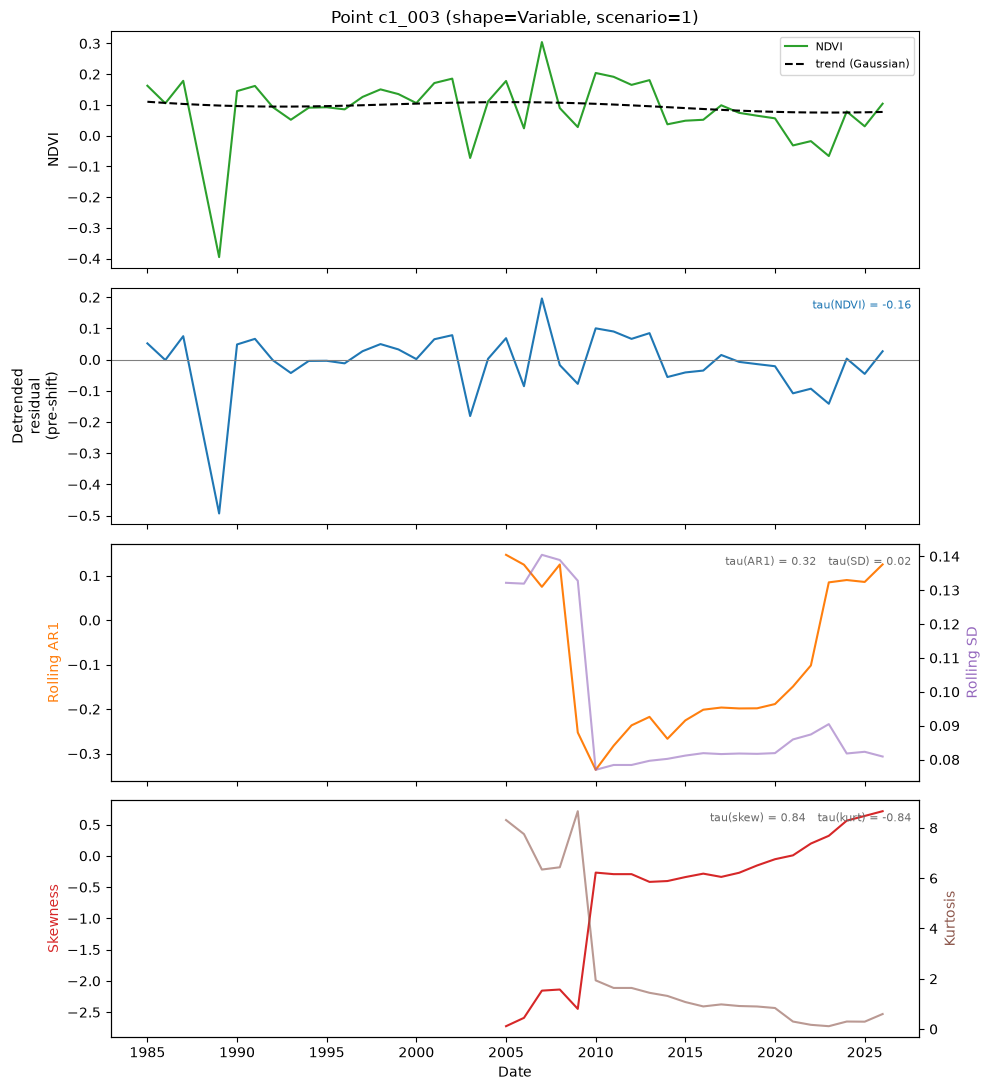

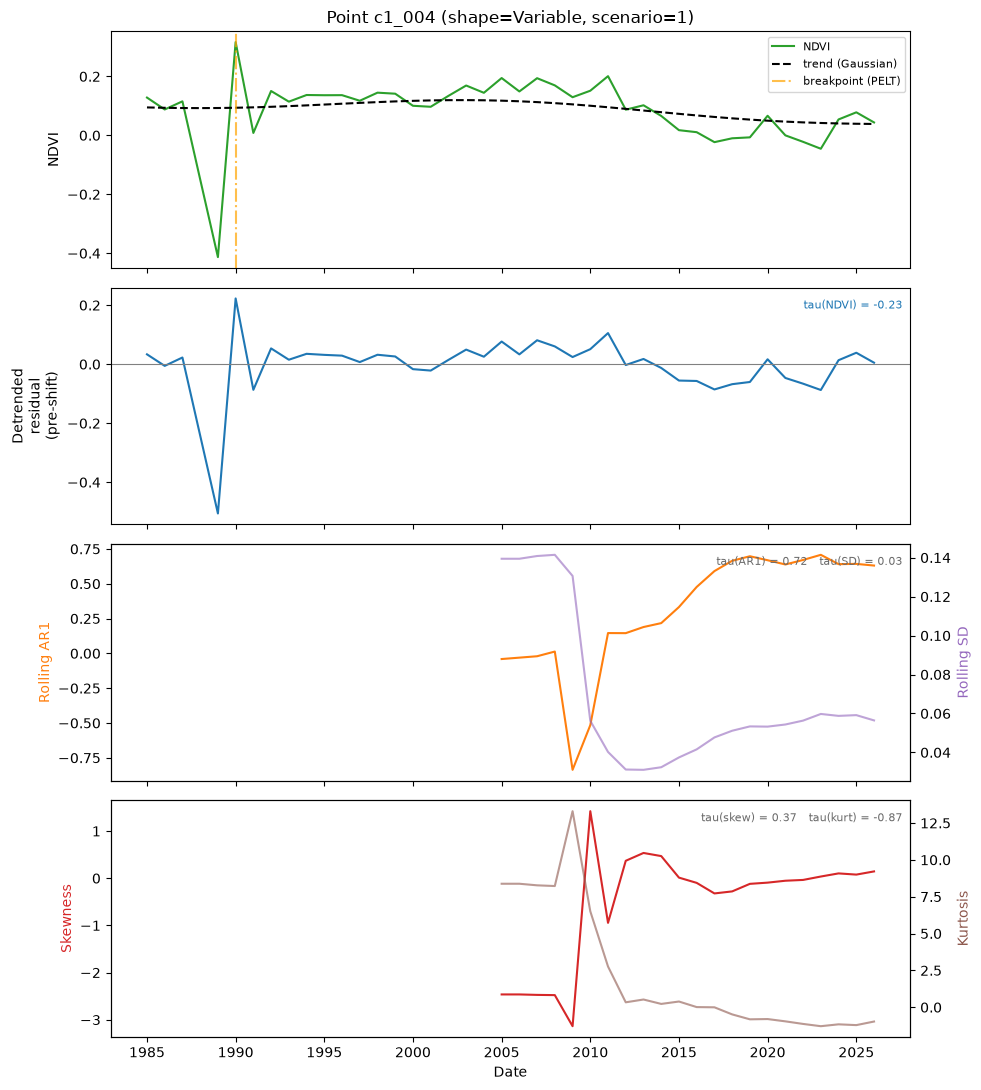

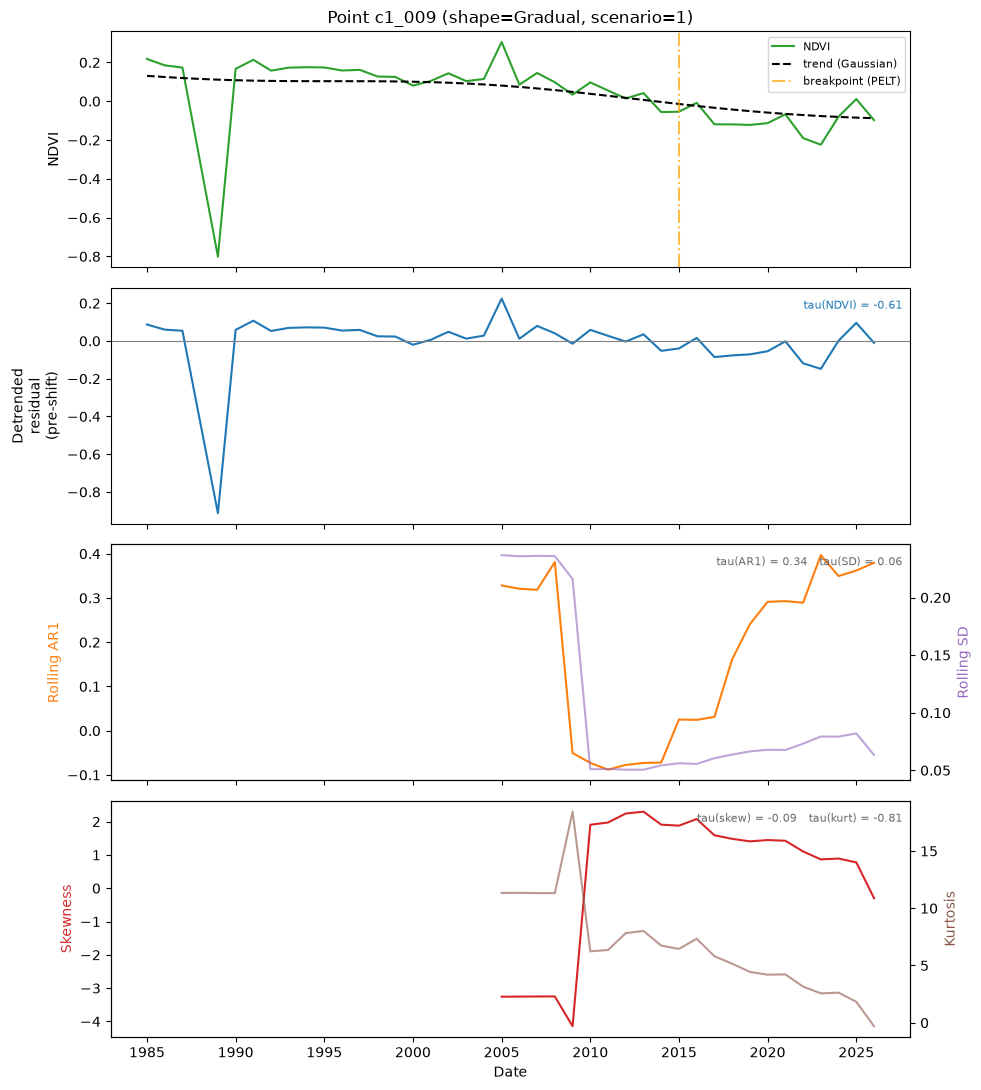

In [119]:
candidates = results_df[(results_df['traj'].isin([1, 2])) & (results_df['scenario'] == 1)]
print(candidates[['point_id', 'traj', 'tau_ndvi', 'tau_sd', 'trajectory_shape']])

for pid in candidates['point_id'].head(3):
    row = results_df[results_df['point_id'] == pid].iloc[0]
    plot_point(pid, detail[pid], row, CONFIG['output_dir'], save=False)

## extra codes

In [120]:
loss_points = results_df[results_df['traj'] == 3]
stable_points = results_df[results_df['traj'] == 1]

print("Median pre-shift years used for AR1/SD/skew/kurtosis calculation:")
print(f"  Loss points:   {loss_points['n_preshift_years'].median()}")
print(f"  Stable points: {stable_points['n_preshift_years'].median()}")

print("\nTrajectory shape breakdown, loss vs stable specifically:")
print("Loss:")
print(loss_points['trajectory_shape'].value_counts())
print("\nStable:")
print(stable_points['trajectory_shape'].value_counts())

Median pre-shift years used for AR1/SD/skew/kurtosis calculation:
  Loss points:   29.0
  Stable points: 29.0

Trajectory shape breakdown, loss vs stable specifically:
Loss:
trajectory_shape
Variable    21
Abrupt      10
None         3
Gradual      1
Name: count, dtype: int64

Stable:
trajectory_shape
Variable    23
Gradual      5
Abrupt       2
Name: count, dtype: int64


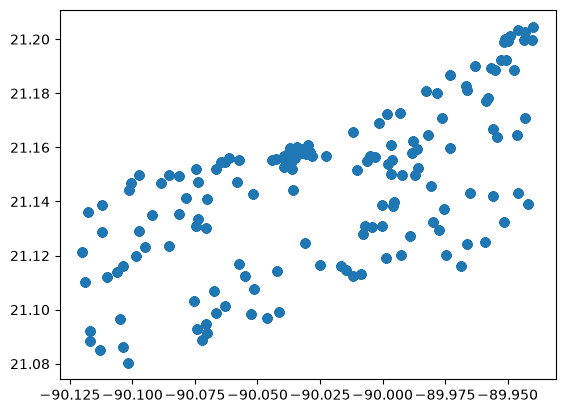

In [113]:
points = pd.read_csv("Sisal_Landsat_annual_max_NDVI_per_point2.csv")
points.head()
lon = points['lon']
lat = points['lat']
traj = points['traj']
coordinates = list(zip(lon, lat))
plt.plot(lon, lat, 'o')

In [114]:
from scipy.stats import kendalltau

df_raw = load_long_csv(CONFIG["input_csv"])
img_count_by_year = df_raw.groupby(df_raw['date'].dt.year)['n_images_that_year'].mean()
print(img_count_by_year)

tau_imgcount_year, _ = kendalltau(img_count_by_year.index, img_count_by_year.values)
print(f"\nKendall tau of (mean image count) vs (year): {tau_imgcount_year:.3f}")

date
1985      6.0
1986     26.0
1987     14.0
1989      1.0
1990      6.0
1991      8.0
1992     18.0
1993     50.0
1994     53.0
1995     50.0
1996     51.0
1997     59.0
1998     53.0
1999     62.0
2000     69.0
2001     63.0
2002     31.0
2003     34.0
2004     50.0
2005     44.0
2006     45.0
2007     40.0
2008     42.0
2009     47.0
2010     42.0
2011     50.0
2012     49.0
2013     73.0
2014    119.0
2015    116.0
2016    129.0
2017    126.0
2018    120.0
2019    129.0
2020    121.0
2021    132.0
2022    151.0
2023    179.0
2024    105.0
2025    125.0
2026     93.0
Name: n_images_that_year, dtype: float64

Kendall tau of (mean image count) vs (year): 0.606


## 1a NDVI correction plots, tau years, n_images

In [115]:
import numpy as np

df_raw = load_long_csv(CONFIG["input_csv"])
df_raw['year_num'] = df_raw['date'].dt.year

# Fit the global image-count effect on ndvi, then subtract it out
coef = np.polyfit(df_raw['n_images_that_year'], df_raw['ndvi'], deg=1)
df_raw['ndvi_corrected'] = df_raw['ndvi'] - np.polyval(coef, df_raw['n_images_that_year'])
print(f"Fitted slope (NDVI per additional image/year): {coef[0]:.5f}")

Fitted slope (NDVI per additional image/year): 0.00207


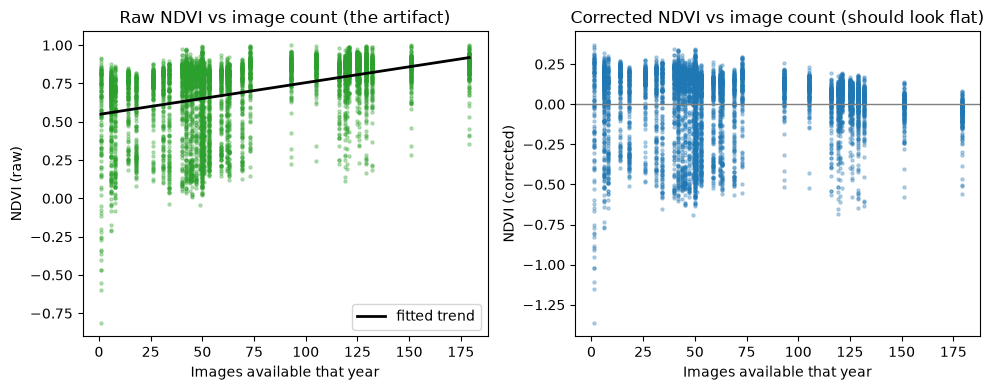

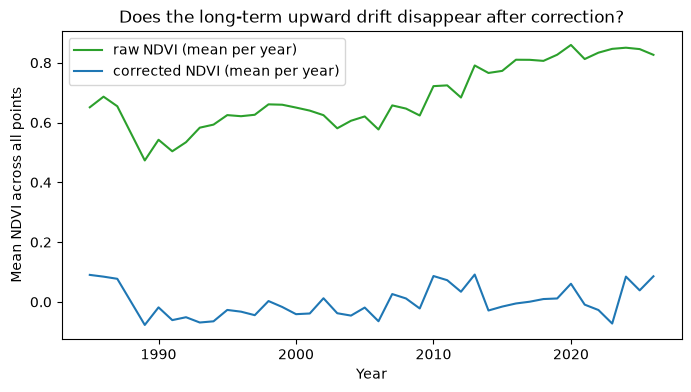

Kendall tau of corrected NDVI vs year: 0.249 (p=0.022)


In [116]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: the artifact itself - raw NDVI rising with image count, plus the fitted line
axes[0].scatter(df_raw['n_images_that_year'], df_raw['ndvi'], s=5, alpha=0.3, color='tab:green')
x_line = np.linspace(df_raw['n_images_that_year'].min(), df_raw['n_images_that_year'].max(), 100)
axes[0].plot(x_line, np.polyval(coef, x_line), color='black', linewidth=2, label='fitted trend')
axes[0].set_xlabel('Images available that year')
axes[0].set_ylabel('NDVI (raw)')
axes[0].set_title('Raw NDVI vs image count (the artifact)')
axes[0].legend()

# Right: after correction, this should look flat - no more relationship with image count
axes[1].scatter(df_raw['n_images_that_year'], df_raw['ndvi_corrected'], s=5, alpha=0.3, color='tab:blue')
axes[1].axhline(0, color='gray', linewidth=1)
axes[1].set_xlabel('Images available that year')
axes[1].set_ylabel('NDVI (corrected)')
axes[1].set_title('Corrected NDVI vs image count (should look flat)')

fig.tight_layout()
plt.show()

year_means = df_raw.groupby('year_num')[['ndvi', 'ndvi_corrected']].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(year_means.index, year_means['ndvi'], label='raw NDVI (mean per year)', color='tab:green')
ax.plot(year_means.index, year_means['ndvi_corrected'], label='corrected NDVI (mean per year)', color='tab:blue')
ax.set_xlabel('Year')
ax.set_ylabel('Mean NDVI across all points')
ax.set_title('Does the long-term upward drift disappear after correction?')
ax.legend()
plt.show()

from scipy.stats import kendalltau

tau_corrected, p_corrected = kendalltau(year_means.index, year_means['ndvi_corrected'])
print(f"Kendall tau of corrected NDVI vs year: {tau_corrected:.3f} (p={p_corrected:.3f})")

In [150]:
results = pd.read_csv("ndvi_analysis_output/ews_summary.csv")
results.head()

,point_id,n_years,n_preshift_years,shift_baseline_mean,shift_baseline_std,shift_drop_threshold,shift_shift_detected,shift_onset_date,shift_tail_mean,shift_recovered,...,p_sd,tau_skew,p_skew,tau_kurtosis,p_kurtosis,trajectory_shape,scenario,traj,lon,lat
0,c10_001,42,42,-0.279229,0.271009,-0.685743,False,NaN,0.026741,NaN,...,0.7475,-0.419913,0.7375,-0.523810,0.8400,NaN,4.0,3,-90.028968,21.158313
1,c10_002,42,42,-0.164486,0.308259,-0.626874,False,NaN,-0.099958,NaN,...,0.3325,0.220779,0.3825,-0.350649,0.7425,Abrupt,3.0,3,-90.033549,21.158583
2,c10_003,42,42,-0.171875,0.280457,-0.592561,False,NaN,0.026446,NaN,...,0.3775,-0.281385,0.7125,-0.272727,0.6750,Abrupt,3.0,3,-90.030046,21.158044
3,c10_004,42,42,-0.139368,0.286895,-0.569710,False,NaN,-0.000303,NaN,...,0.3750,-0.056277,0.5475,-0.160173,0.5950,Abrupt,3.0,3,-90.029507,21.157774
4,c10_005,42,42,-0.112327,0.157474,-0.348538,False,NaN,-0.131344,NaN,...,0.5900,0.220779,0.3700,-0.393939,0.7225,NaN,2.0,3,-89.954594,21.163972
